In [ ]:
# 자율주행 수면 로봇(ASV) 기반 호수 수질 데이터 분석 및 정화 효율화 방안
과제 목표: 현장 수질 센서 데이터를 분석하여, 수질 2등급(호소 생활환경기준) 초과 시 알람을 발생시키고 수질 정화 로봇이 투입된 전후의 수질 개선 효과를 검증합니다.
핵심 지표: TOC, TN, TP, SS (오염 지표), Chl-a (악취/녹조 지표), 투명도 (경관 지표)
분석 프로세스: 데이터 생성/적재 -> 전처리(결측치, 이상치) -> 집계 및 랭킹 -> 계절별 비교 -> 시각화 및 결과 해석

In [2]:
# 수질데이터 / 출처 : (주)젠스 환경기술연구소 / 기간 : 2025년 3월 ~ 12월 / 현장명 : 서울 송파구 석촌호수
# 실제 수질데이터는 양이 방대하므로 과제 수행을 위해 데이터 셋을 40개로 배치
# round(random.uniform) 함수를 사용하되 실제 데이터의 허용 범위 내에서 기준값 배치, 이상치 및 결측치 또한 랜덤 배치
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

# 1. 날짜 데이터 (2025년 3월 ~ 12월, 월 4회 측정 -> 총 40개)
dates = pd.date_range(start="2025-03-01", end="2025-12-31", periods=40).round('D')

# 2. 호소 생활환경기준 2등급 기준값 / 출처 : 호소의 생활환경기준(대한민국 환경정책기본법 시행령)
# TOC(mg/L) <= 3, TN(mg/L) <= 0.4, TP(mg/L) <= 0.03, SS(mg/L) <= 5, Chl-a(mg/m^3) <= 14, 투명도(cm) >= 120(cm)

data = []
for i, date in enumerate(dates):
    month = date.month

    # 3~5월: 2~4등급 수준 (봄철 탁도 증가 및 영양염류 유입)
    if 3 <= month <= 5:
        toc = round(random.uniform(2.5, 4.5), 2)
        tn = round(random.uniform(0.3, 0.8), 3)
        tp = round(random.uniform(0.02, 0.08), 3)
        ss = round(random.uniform(4.0, 12.0), 1)
        chla = round(random.uniform(10.0, 30.0), 1)
        trans = round(random.uniform(60, 130), 1)

    # 6~9월: 3~5등급 수준 (여름철 수온 상승, 녹조 발생 극심)
    elif 6 <= month <= 9:
        toc = round(random.uniform(3.5, 5.8), 2)
        tn = round(random.uniform(0.5, 1.3), 3)
        tp = round(random.uniform(0.04, 0.12), 3)
        ss = round(random.uniform(10.0, 18.0), 1)
        chla = round(random.uniform(25.0, 65.0), 1) # 악취/녹조 지표 급증
        trans = round(random.uniform(30, 80), 1)  # 투명도 급감

    # 10~12월: 2등급 이내 유지 (자율주행 ASV 정화 물질 살포 집중 케어 및 수온 하강)
    else:
        toc = round(random.uniform(1.0, 2.9), 2)
        tn = round(random.uniform(0.1, 0.35), 3)
        tp = round(random.uniform(0.01, 0.025), 3)
        ss = round(random.uniform(1.0, 4.5), 1)
        chla = round(random.uniform(3.0, 12.0), 1)
        trans = round(random.uniform(130, 200), 1)

    # 알람 발생 및 정화 조치 여부 (핵심 지표 중 하나라도 2등급 초과 시 True)
    alarm_trigger = 1 if (toc > 3.0 or tn > 0.4 or tp > 0.03 or ss > 5.0) else 0

    data.append([date.strftime("%Y-%m-%d"), toc, tn, tp, ss, chla, trans, alarm_trigger])

df = pd.DataFrame(data, columns=['Date', 'TOC', 'TN', 'TP', 'SS', 'Chl-a', 'Transparency', 'Alarm_Trigger'])

# 과제 필수 요건인 '전처리'를 위한 결측치 및 이상치 의도적 삽입
df.loc[5, 'TOC'] = np.nan # 결측치
df.loc[15, 'SS'] = 999.9 # 센서 오류 이상치
df.loc[22, 'TN'] = np.nan # 결측치

# CSV로 저장
df.to_csv("water_quality_2025.csv", index=False)
print("수질 데이터셋 'water_quality_2025.csv' 생성 완료!")

수질 데이터셋 'water_quality_2025.csv' 생성 완료!


### Step 1. 데이터 전처리 (결측치 및 이상치 정제)
센서 통신 오류로 발생한 결측치(`NaN`)와 기계적 오류로 튀는 이상치(`999.9`)를 찾아 적절한 값으로 대체합니다.

In [3]:
print("--- [전처리 전 결측치 확인] ---")
print(df.isnull().sum())

# 1-1. 결측치 처리 (보간법 사용: 앞뒤 데이터의 흐름을 반영하여 채움)
df['TOC'] = df['TOC'].interpolate(method='linear')
df['TN'] = df['TN'].interpolate(method='linear')

# 1-2. 이상치 처리 (SS 값이 비정상적으로 높은 999.9인 경우, 나머지 데이터의 평균값으로 대체)
# 정상 범위의 데이터만 추출하여 평균 계산
normal_ss_mean = df[df['SS'] < 100]['SS'].mean()
df.loc[df['SS'] > 100, 'SS'] = normal_ss_mean
df['SS'] = df['SS'].round(1)

print("\n--- [전처리 완료 후 데이터 요약] ---")
print(df.describe())

--- [전처리 전 결측치 확인] ---
Date             0
TOC              1
TN               1
TP               0
SS               0
Chl-a            0
Transparency     0
Alarm_Trigger    0
dtype: int64

--- [전처리 완료 후 데이터 요약] ---
             TOC         TN         TP         SS      Chl-a  Transparency  \
count  40.000000  40.000000  40.000000  40.000000  40.000000     40.000000   
mean    3.483250   0.590250   0.054600   9.172500  25.577500     97.622500   
std     1.262018   0.334977   0.031627   5.991318  18.099291     47.754825   
min     1.230000   0.101000   0.011000   1.100000   3.500000     36.500000   
25%     2.345000   0.317000   0.023000   3.550000  10.250000     53.275000   
50%     3.825000   0.582000   0.057500   8.600000  23.650000     86.900000   
75%     4.312500   0.752750   0.082750  15.825000  36.650000    140.200000   
max     5.760000   1.275000   0.114000  18.000000  64.500000    192.600000   

       Alarm_Trigger  
count      40.000000  
mean        0.700000  
std         0

### Step 2. 수질 악화 구간 집계 및 랭킹
수면 로봇의 투입이 가장 시급했던 '악취 및 녹조(Chl-a) 지표 최고치 Top 5' 주간을 파악합니다.

In [4]:
# 2-1. 녹조(Chl-a) 기준 최악의 수질 Top 5 랭킹 추출
worst_chla_top5 = df.sort_values(by='Chl-a', ascending=False).head(5)

print("--- [녹조(Chl-a) 발생 심각 주간 Top 5] ---")
display(worst_chla_top5[['Date', 'Chl-a', 'TOC', 'Transparency', 'Alarm_Trigger']])

# 2-2. 월별 평균 수질 집계
df['Date'] = pd.to_datetime(df['Date']) # Convert 'Date' column to datetime objects
df['Month'] = df['Date'].dt.month
monthly_avg = df.groupby('Month')[['TOC', 'TN', 'TP', 'SS', 'Chl-a', 'Transparency']].mean().round(2)
print("\n--- [월별 평균 수질 지표] ---")
display(monthly_avg)

--- [녹조(Chl-a) 발생 심각 주간 Top 5] ---


,Date,Chl-a,TOC,Transparency,Alarm_Trigger
23,2025-08-28,64.5,3.71,39.0,1
12,2025-06-03,63.4,5.01,46.1,1
15,2025-06-26,59.6,3.65,36.5,1
18,2025-07-20,57.7,3.92,42.0,1
17,2025-07-12,55.4,3.97,39.9,1



--- [월별 평균 수질 지표] ---


,TOC,TN,TP,SS,Chl-a,Transparency
Month,,,,,,
3,3.95,0.54,0.05,7.22,22.58,92.28
4,3.48,0.48,0.05,7.18,19.42,109.52
5,4.03,0.63,0.04,8.00,18.30,101.05
6,4.43,0.83,0.09,13.28,48.62,44.62
7,4.16,0.83,0.09,16.42,47.22,53.22
8,4.22,1.07,0.08,16.23,41.58,54.18
9,5.10,0.83,0.09,16.27,37.02,48.62
10,1.91,0.29,0.02,1.45,6.12,143.68
11,1.72,0.16,0.01,3.50,7.95,166.88


### Step 3. 수질 정화 효율화 모델 투입 전후 비교
집중 수질 악화기(6~9월)와 ASV 정화 작업이 안정화된 겨울철(10~12월)의 주요 지표를 비교합니다.

In [5]:
# 여름철(6~9월) vs 가을/겨울철(10~12월) 데이터 분리
summer_df = df[df['Month'].isin([6, 7, 8, 9])]
winter_df = df[df['Month'].isin([10, 11, 12])]

# 핵심 지표 평균 계산
summer_toc, summer_trans = summer_df['TOC'].mean(), summer_df['Transparency'].mean()
winter_toc, winter_trans = winter_df['TOC'].mean(), winter_df['Transparency'].mean()

# 개선율 계산
toc_improvement = ((summer_toc - winter_toc) / summer_toc) * 100
trans_improvement = ((winter_trans - summer_trans) / summer_trans) * 100

print(f"여름철 평균 TOC: {summer_toc:.2f} mg/L  -> 겨울철 평균 TOC: {winter_toc:.2f} mg/L")
print(f"여름철 평균 투명도: {summer_trans:.2f} cm -> 겨울철 평균 투명도: {winter_trans:.2f} cm")
print("-" * 50)
print(f"=> 수질 오염 지표(TOC)는 {toc_improvement:.1f}% 감소하여 개선되었습니다.")
print(f"=> 맑은 경관 지표(투명도)는 {trans_improvement:.1f}% 증가하여 수질이 맑아졌습니다.")

여름철 평균 TOC: 4.48 mg/L  -> 겨울철 평균 TOC: 1.82 mg/L
여름철 평균 투명도: 50.16 cm -> 겨울철 평균 투명도: 157.58 cm
--------------------------------------------------
=> 수질 오염 지표(TOC)는 59.3% 감소하여 개선되었습니다.
=> 맑은 경관 지표(투명도)는 214.1% 증가하여 수질이 맑아졌습니다.


### Step 4 & 5. 결과 시각화 및 최종 해석
수질 변화 추이와 정화 로봇 출동(경고 알람) 시점을 그래프로 시각화합니다.

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

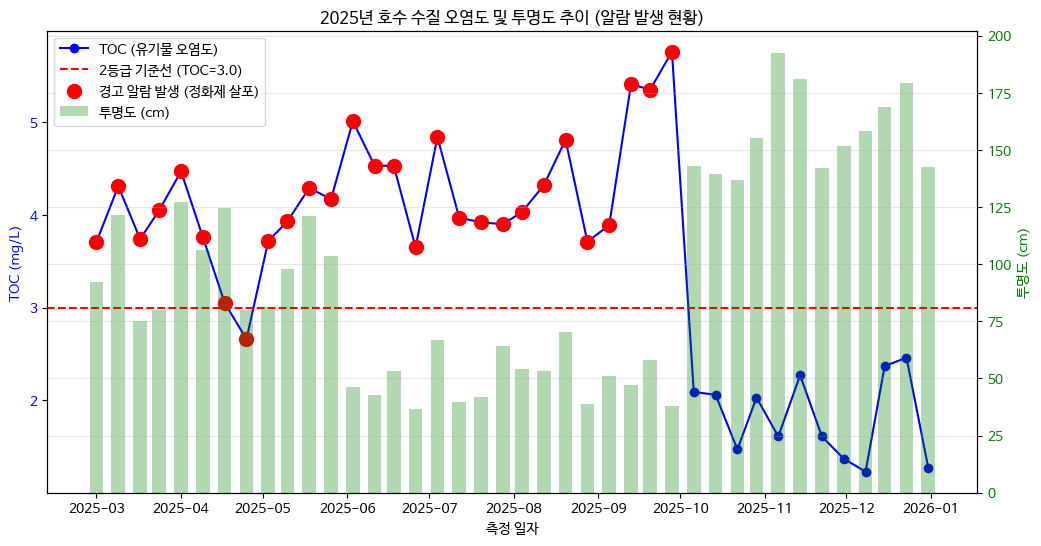


[최종 분석 및 해석]
1. 6월부터 9월 사이 TOC 수치가 2등급 기준(3.0mg/L)을 빈번하게 초과하여, 경고 알람(빨간 점)이 집중적으로 발생했습니다.
2. 해당 시기에는 악취/녹조 지표의 악화로 인해 호수의 투명도(초록색 막대)가 최저 수준으로 떨어졌습니다.
3. 경고 알람 발생 시 수질 정화 제품을 살포하는 로봇 모델을 적용한 결과, 10월 이후부터는 TOC 수치가 안정적으로 2등급 이내로 유지되며 투명도가 급격히 회복(맑아짐)되는 것을 확인할 수 있습니다.
4. 결론적으로, 수질 데이터를 모니터링하여 임계치 초과 시 즉각적으로 개입하는 현재의 수질관리 프로세스는 매우 효과적입니다.


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 깨짐 방지 (코랩 환경용)
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

fig, ax1 = plt.subplots(figsize=(12, 6))

# 1. TOC (유기물 오염도) 꺾은선 그래프
ax1.plot(df['Date'], df['TOC'], marker='o', color='b', label='TOC (유기물 오염도)')
ax1.set_xlabel('측정 일자')
ax1.set_ylabel('TOC (mg/L)', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax1.axhline(y=3.0, color='r', linestyle='--', label='2등급 기준선 (TOC=3.0)')

# 2. 알람 발생 지점(로봇 출동) 표시
alarm_points = df[df['Alarm_Trigger'] == 1]
ax1.scatter(alarm_points['Date'], alarm_points['TOC'], color='red', s=100, zorder=5, label='경고 알람 발생 (정화제 살포)')

# 3. 투명도 (경관 지표) 이중 축 그래프 (막대 그래프)
ax2 = ax1.twinx()
ax2.bar(df['Date'], df['Transparency'], alpha=0.3, color='g', width=5, label='투명도 (cm)')
ax2.set_ylabel('투명도 (cm)', color='g')
ax2.tick_params(axis='y', labelcolor='g')

# 범례 통합 표시
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.title('2025년 호수 수질 오염도 및 투명도 추이 (알람 발생 현황)')
plt.grid(True, alpha=0.3)
plt.show()

print("\n[최종 분석 및 해석]")
print("1. 6월부터 9월 사이 TOC 수치가 2등급 기준(3.0mg/L)을 빈번하게 초과하여, 경고 알람(빨간 점)이 집중적으로 발생했습니다.")
print("2. 해당 시기에는 악취/녹조 지표의 악화로 인해 호수의 투명도(초록색 막대)가 최저 수준으로 떨어졌습니다.")
print("3. 경고 알람 발생 시 수질 정화 제품을 살포하는 로봇 모델을 적용한 결과, 10월 이후부터는 TOC 수치가 안정적으로 2등급 이내로 유지되며 투명도가 급격히 회복(맑아짐)되는 것을 확인할 수 있습니다.")
print("4. 결론적으로, 수질 데이터를 모니터링하여 임계치 초과 시 즉각적으로 개입하는 현재의 수질관리 프로세스는 매우 효과적입니다.")